In [1]:
pip install pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
file = "../Dataset/final_sdb_dataset_clean.csv"
df = pd.read_csv(file)
df_shallow = df[(df['depth'] >= 0) & (df['depth'] <= 30)].copy()

print(f"Original rows: {len(df)} | Rows after filtering (depth <= 30): {len(df_shallow)}")

Original rows: 11676 | Rows after filtering (depth <= 30): 4548


In [3]:
df_arabian_sea = df_shallow[(df_shallow['longitude'] > 48) & (df_shallow['longitude'] < 60)].copy()
df_strait_of_hormuz = df_shallow[(df_shallow['longitude'] > 65) & (df_shallow['longitude'] < 70)].copy()
df_bay_of_bengal = df_shallow[df_shallow['longitude'] >= 70].copy()

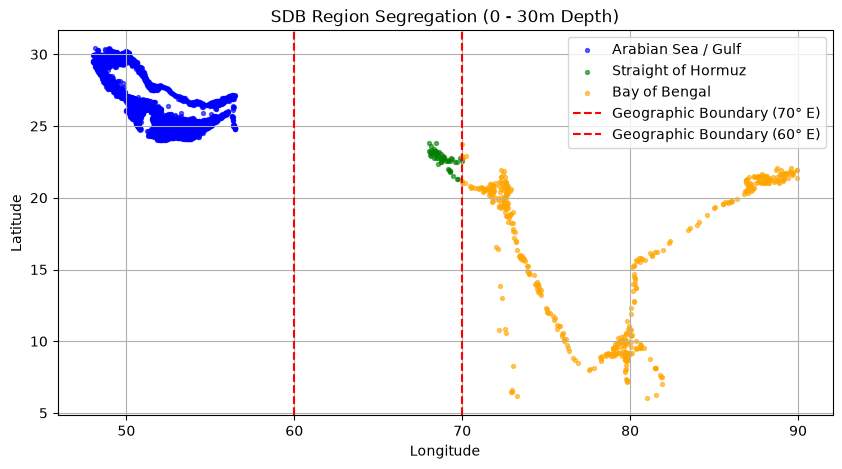

In [4]:
plt.figure(figsize=(10, 5))
plt.scatter(df_arabian_sea['longitude'], df_arabian_sea['latitude'], c='blue', label='Arabian Sea / Gulf', s=8, alpha=0.6)
plt.scatter(df_strait_of_hormuz['longitude'], df_strait_of_hormuz['latitude'], c='green', label='Straight of Hormuz', s=8, alpha=0.6)
plt.scatter(df_bay_of_bengal['longitude'], df_bay_of_bengal['latitude'], c='orange', label='Bay of Bengal', s=8, alpha=0.6)
plt.axvline(x=70, color='red', linestyle='--', label='Geographic Boundary (70° E)')
plt.axvline(x=60, color='red', linestyle='--', label='Geographic Boundary (60° E)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('SDB Region Segregation (0 - 30m Depth)')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
features = ['blue_band', 
            'green_band', 
            'log_blue', 
            'log_green', 
            'bg_ratio', 
            'stumpf_ratio']

In [6]:
X_all = df_shallow[features]
y_all = df_shallow['depth']

X_tr_all, X_te_all, y_tr_all, y_te_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

In [7]:
scaler_global = StandardScaler()
X_tr_all_scaled = scaler_global.fit_transform(X_tr_all)
X_te_all_scaled = scaler_global.transform(X_te_all)

In [8]:
mlp_global = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True
)
mlp_global.fit(X_tr_all_scaled, y_tr_all)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by atleast ``tol`` for ``n_iter_no_change`` consecutive epochs.Only effective when solver='sgd' or 'adam'.",True
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solv

In [9]:
y_pred_all = mlp_global.predict(X_te_all_scaled)

In [10]:
mae_all = mean_absolute_error(y_te_all, y_pred_all)
rmse_all = root_mean_squared_error(y_te_all, y_pred_all)
r2_all = r2_score(y_te_all, y_pred_all)

print("=" * 45)
print("  MLP GLOBAL MODEL: ALL REGIONS")
print("=" * 45)
print(f"MAE  : {mae_all:.4f} m")
print(f"RMSE : {rmse_all:.4f} m")
print(f"R²   : {r2_all:.4f}\n")

  MLP GLOBAL MODEL: ALL REGIONS
MAE  : 4.9935 m
RMSE : 6.3775 m
R²   : 0.4836



  MLP SEPARATE REGIONAL MODELS
=== Arabian Sea / Gulf (N=4067) ===
  MAE  : 4.6114 m
  RMSE : 6.0592 m
  R²   : 0.5168

=== Strait of Hormuz (N=54) ===
  MAE  : 4.0939 m
  RMSE : 5.0220 m
  R²   : 0.3499

=== Bay of Bengal (N=427) ===
  MAE  : 5.6702 m
  RMSE : 7.1076 m
  R²   : 0.3135



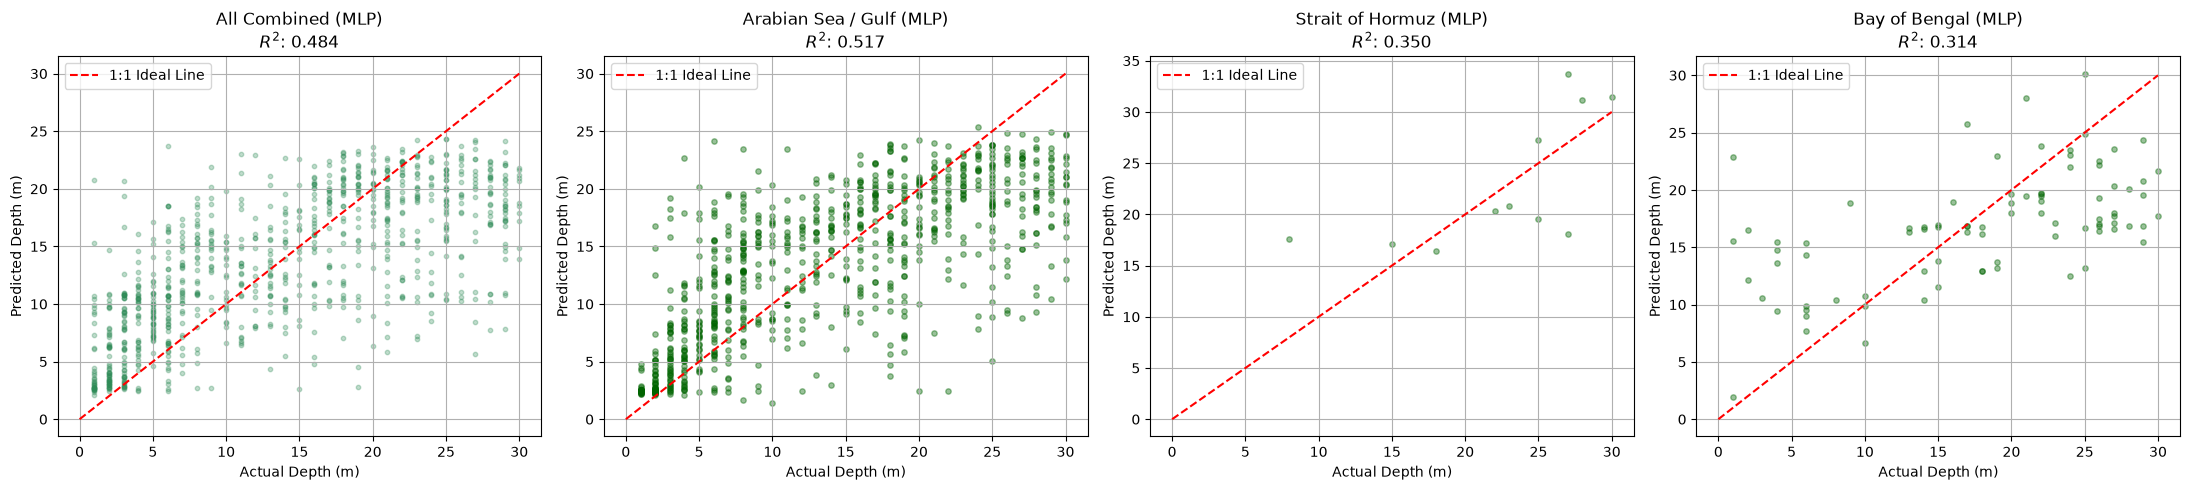

In [11]:
regions = [
    ('Arabian Sea / Gulf', df_arabian_sea),
    ('Strait of Hormuz', df_strait_of_hormuz),
    ('Bay of Bengal', df_bay_of_bengal)
]

mlp_models = {}

print("=" * 45)
print("  MLP SEPARATE REGIONAL MODELS")
print("=" * 45)

# Setup subplots: 1 row with 4 plots (Combined + 3 Regions)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Plot Combined Results in First Subplot
axes[0].scatter(y_te_all, y_pred_all, alpha=0.3, s=10, color='seagreen')
axes[0].plot([0, 30], [0, 30], 'r--', label='1:1 Ideal Line')
axes[0].set_xlabel('Actual Depth (m)')
axes[0].set_ylabel('Predicted Depth (m)')
axes[0].set_title(f'All Combined (MLP)\n$R^2$: {r2_all:.3f}')
axes[0].grid(True)
axes[0].legend()

# Iterate through individual regions
for idx, (name, region_df) in enumerate(regions, start=1):
    if len(region_df) == 0:
        print(f"Skipping {name}: No samples available.")
        continue
        
    X_reg = region_df[features]
    y_reg = region_df['depth']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_reg, y_reg, test_size=0.2, random_state=42
    )
    
    # Scale features per region to prevent data leakage
    scaler_region = StandardScaler()
    X_train_scaled = scaler_region.fit_transform(X_train)
    X_test_scaled = scaler_region.transform(X_test)
    
    # Fit individual MLP model
    mlp = MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42,
        early_stopping=True
    )
    mlp.fit(X_train_scaled, y_train)
    mlp_models[name] = mlp
    
    # Predict & Evaluate
    y_pred = mlp.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"=== {name} (N={len(region_df)}) ===")
    print(f"  MAE  : {mae:.4f} m")
    print(f"  RMSE : {rmse:.4f} m")
    print(f"  R²   : {r2:.4f}\n")
    
    # Plot Region Results
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.4, s=15, color='darkgreen')
    ax.plot([0, 30], [0, 30], 'r--', label='1:1 Ideal Line')
    ax.set_xlabel('Actual Depth (m)')
    ax.set_ylabel('Predicted Depth (m)')
    ax.set_title(f'{name} (MLP)\n$R^2$: {r2:.3f}')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()